## Setup

Import required libraries and create the emulator.

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from meteor import MeteorInterface

print("✅ Imports complete")

✅ Imports complete


In [3]:
# Create and train emulator (uses cached models if available)
emulator = MeteorInterface(
    model='NorESM2-MM',
    variables=['tas', 'pr'],
    cache_dir='../cache'
)

print(f"Emulator created for: {emulator.variables}")
print(f"Model: {emulator.model}")

Emulator created for: ['tas', 'pr']
Model: NorESM2-MM


In [4]:
# Train models
emulator.train(verbose=True)

Training METEOR emulator for NorESM2-MM
Variables: tas, pr

🔧 Training TAS...
   → Training pattern scaling model...
      ⚠️  Cache miss: Model name mismatch: expected 'cmip6-NorESM2-MM-aer', found 'cmip6-NorESM2-MM-aer-tas'
🔧 Preparing pattern scaling training data for NorESM2-MM...
   ✅ Training data prepared for experiments: ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 351 emission records
   ✅ Config: 1750-2100, emissions start: 1850
📦 Loading cached pattern scaling model from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
   → Training noise model...
Model loaded from ../cache/noise_models/NorESM2-MM_tas_noise_model.pkl
      ✓ Using cached noise model
   ✅ TAS training complete

🔧 Training PR...
   → Training pattern scaling model...
      ⚠️  Cache miss: Model

✅ Pattern scaling model loaded from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-pr_pattern_scaling.pkl
   → Training noise model...
      ⚠️  Training new noise model...
      → Using ssp245 pattern prediction for training
      → Temperature trajectory: 251 years
   Fetched piControl baseline for NorESM2-MM pr: 0.000
40 2
Noise generator fitted successfully.
   - PCA modes: 40
   - Variance explained: 44.68%
   - VARX lag order: 2
   - Exogenous vars: none (pure VAR)
Model saved to ../cache/noise_models/NorESM2-MM_pr_noise_model.pkl
   → Fitting gamma transform...
      Reason: Ensure positive-only values (precipitation cannot be negative)
   ✅ PR training complete

✅ All variables trained successfully


## Example 1: Simple Climate Ensemble

Generate 100 realizations of global temperature and precipitation for SSP2-4.5.

In [5]:
# Generate ensemble
ensemble = emulator.generate_ensemble_outputs(
    scenario='ssp245',
    start_year=1850,
    end_year=2100,
    n_realizations=3,
    timeseries=['global']  # Global mean
)

# Access results
global_temp = ensemble['tas'].timeseries['global']  # Shape: (100, 3012 months)
print(f"Ensemble shape: {global_temp.shape}")
print(f"2100 warming: {global_temp[:, -1].mean():.2f} ± {global_temp[:, -1].std():.2f} K")

Generating ensemble for ssp245
  Years: 1850-2100
  Realizations: 3

📊 Generating TAS...
   → Time series: 1 aggregations
      → Computing pattern scaling for tas, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 3 stochastic PC realizations...
      • global
   ✅ TAS complete

📊 Generating PR...
   → Time series: 1 aggregations
      → Computing pattern scaling for pr, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for pr...
      → Using 1850 baseline for PR instead of piControl
      → Generating 3 stochastic PC realizations...
      • global
   ✅ PR complete

✅ Generation complete
Ensemble shape: (3, 3012)
2100 warming: 0.63 ± 0.12 K


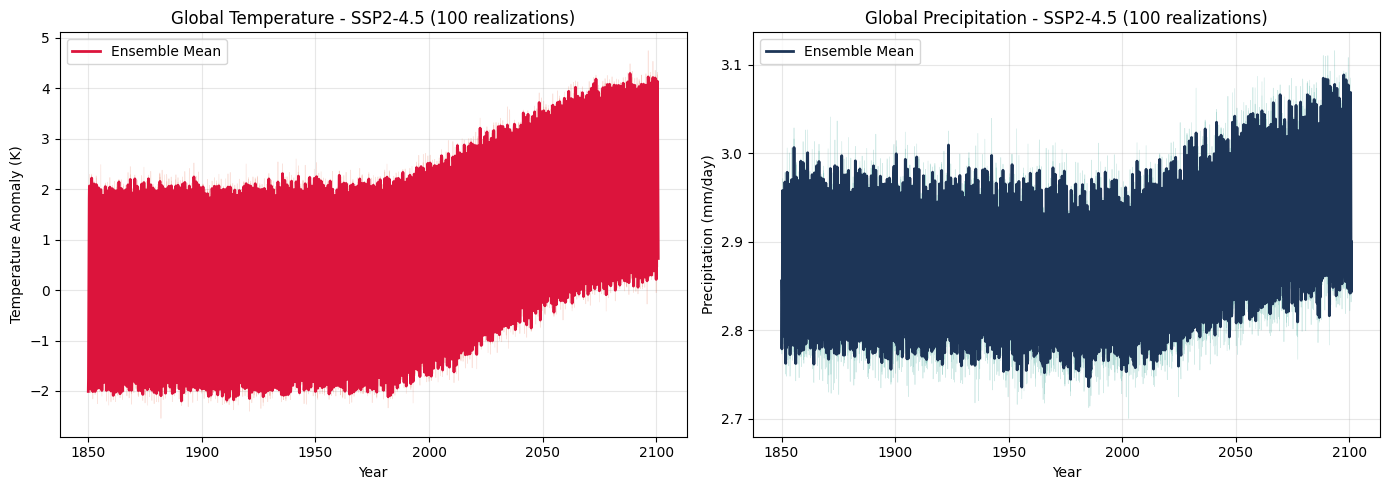

✅ Example 1 complete


In [6]:
# Plot: Global temperature ensemble
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convert monthly to annual for plotting
n_months = global_temp.shape[1]
years = 1850 + np.arange(n_months) / 12

# Temperature
ax = axes[0]
for i in range(min(20, 3)):
    ax.plot(years, global_temp[i, :], alpha=0.2, color='#E76F51', linewidth=0.5)
ax.plot(years, global_temp.mean(axis=0), color='#DC143C', linewidth=2, label='Ensemble Mean')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature Anomaly (K)')
ax.set_title('Global Temperature - SSP2-4.5 (100 realizations)')
ax.legend()
ax.grid(True, alpha=0.3)

# Precipitation
global_pr = ensemble['pr'].timeseries['global'] * 86400  # Convert to mm/day
ax = axes[1]
for i in range(min(20, 3)):
    ax.plot(years, global_pr[i, :], alpha=0.2, color='#2A9D8F', linewidth=0.5)
ax.plot(years, global_pr.mean(axis=0), color='#1D3557', linewidth=2, label='Ensemble Mean')
ax.set_xlabel('Year')
ax.set_ylabel('Precipitation (mm/day)')
ax.set_title('Global Precipitation - SSP2-4.5 (100 realizations)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Example 1 complete")

## Example 2: Regional and City-Scale Projections

Add spatial detail with regional means and specific locations.

In [7]:
# Generate multiple spatial scales
ensemble_multi = emulator.generate_ensemble_outputs(
    scenario='ssp245',
    start_year=1850,
    end_year=2100,
    n_realizations=3,
    timeseries=[
        'global',
        'regional:NEU',  # Northern Europe (AR6 region)
        'regional:EAS',  # East Asia
        'point:59.9,10.8',  # Oslo coordinates (lat, lon)
        'point:28.6,77.2'   # Delhi
    ]
)

# Access different scales
neu_temp = ensemble_multi['tas'].timeseries['regional:NEU']
oslo_temp = ensemble_multi['tas'].timeseries['point:59.9,10.8']

print(f"Northern Europe shape: {neu_temp.shape}")
print(f"Oslo shape: {oslo_temp.shape}")

Generating ensemble for ssp245
  Years: 1850-2100
  Realizations: 3

📊 Generating TAS...
   → Time series: 5 aggregations
      → Computing pattern scaling for tas, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 3 stochastic PC realizations...
      • global
      • regional:NEU
      • regional:EAS
      • point:59.9,10.8
[-90.         -89.05759162 -88.11518325 -87.17277487 -86.23036649
 -85.28795812 -84.34554974 -83.40314136 -82.46073298 -81.51832461
 -80.57591623 -79.63350785 -78.69109948 -77.7486911  -76.80628272
 -75.86387435 -74.92146597 -73.97905759 -73.03664921 -72.09424084
 -71.15183246 -70.20942408 -69.26701571 -68.32460733 -67.38219895
 -66.43979058 -65.4973822  -64.55497382 -63.61256545 -62.67015707
 -61.72774869 -60.78534031 -59.84293194 -58.90052356 -57.95811518
 -57.01570681 -56.07329843 -55.13089005 -54.18848168 -53.2460733
 -52.30

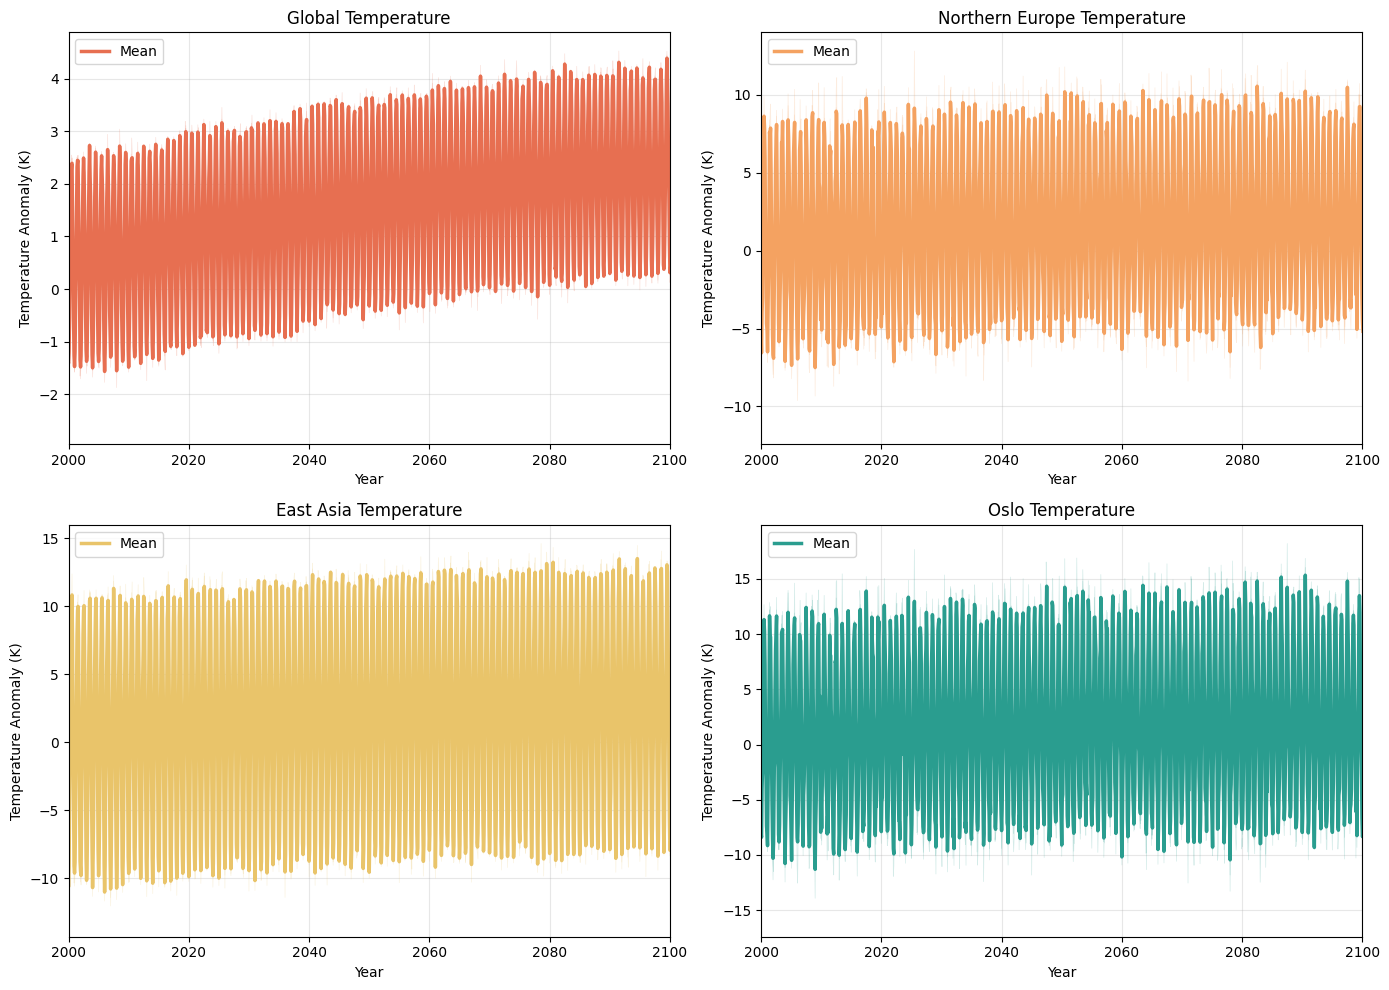

✅ Example 2 complete


In [8]:
# Plot: Multi-scale comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

locations = [
    ('global', 'Global', '#E76F51'),
    ('regional:NEU', 'Northern Europe', '#F4A261'),
    ('regional:EAS', 'East Asia', '#E9C46A'),
    ('point:59.9,10.8', 'Oslo', '#2A9D8F')
]

for idx, (key, name, color) in enumerate(locations):
    ax = axes[idx // 2, idx % 2]
    data = ensemble_multi['tas'].timeseries[key]
    
    # Plot ensemble members
    for i in range(min(10, 3)):
        ax.plot(years, data[i, :], alpha=0.2, color=color, linewidth=0.5)
    
    # Plot mean
    ax.plot(years, data.mean(axis=0), color=color, linewidth=2.5, label='Mean')
    ax.set_xlabel('Year')
    ax.set_ylabel('Temperature Anomaly (K)')
    ax.set_title(f'{name} Temperature')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim([2000, 2100])

plt.tight_layout()
plt.show()

print("✅ Example 2 complete")

## Example 3: Climate Impact Metrics

Calculate heating and cooling degree days automatically.

In [9]:
ensemble_impacts = emulator.generate_ensemble_outputs(
    scenario='ssp245',
    start_year=1850,
    end_year=2100,
    n_realizations=3,
    timeseries=['point:59.9,10.8'],  # Oslo
    impacts={
        'tas': {
            'degree_days': {
                'hdd_base': 18.0,  # Heating degree days
                'cdd_base': 18.0   # Cooling degree days
            }
        }
    }
)

# Access impact metrics (annual values)
hdd = ensemble_impacts['tas'].impacts['hdd']['point:59.9,10.8']  # Shape: (100, 251 years)
cdd = ensemble_impacts['tas'].impacts['cdd']['point:59.9,10.8']

print(f"HDD shape: {hdd.shape}")
print(f"2020 HDD: {hdd[:, 170].mean():.0f} degree-days")
print(f"2100 HDD: {hdd[:, -1].mean():.0f} degree-days")
print(f"HDD change: {((hdd[:, -1].mean() - hdd[:, 170].mean()) / hdd[:, 170].mean() * 100):.1f}%")

Generating ensemble for ssp245
  Years: 1850-2100
  Realizations: 3

📊 Generating TAS...
   → Time series: 1 aggregations
      → Computing pattern scaling for tas, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 3 stochastic PC realizations...
      • point:59.9,10.8
[-90.         -89.05759162 -88.11518325 -87.17277487 -86.23036649
 -85.28795812 -84.34554974 -83.40314136 -82.46073298 -81.51832461
 -80.57591623 -79.63350785 -78.69109948 -77.7486911  -76.80628272
 -75.86387435 -74.92146597 -73.97905759 -73.03664921 -72.09424084
 -71.15183246 -70.20942408 -69.26701571 -68.32460733 -67.38219895
 -66.43979058 -65.4973822  -64.55497382 -63.61256545 -62.67015707
 -61.72774869 -60.78534031 -59.84293194 -58.90052356 -57.95811518
 -57.01570681 -56.07329843 -55.13089005 -54.18848168 -53.2460733
 -52.30366492 -51.36125654 -50.41884817 -49.47643979 -48.5340314

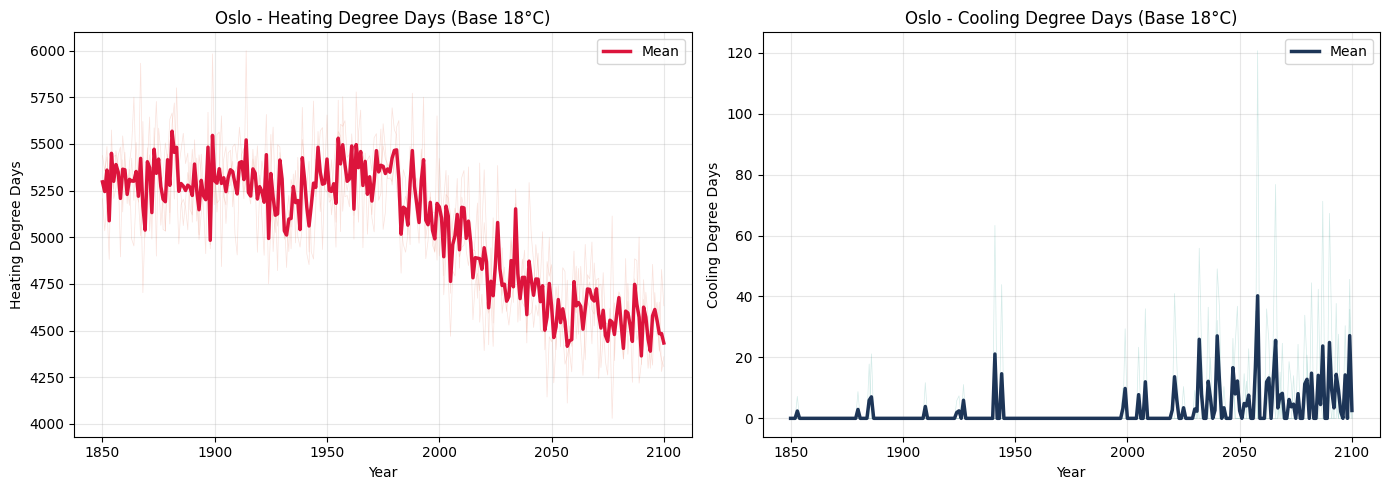

✅ Example 3 complete


In [10]:
# Plot: Degree days
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

years_annual = 1850 + np.arange(hdd.shape[1])

# HDD
ax = axes[0]
for i in range(min(20, 3)):
    ax.plot(years_annual, hdd[i, :], alpha=0.2, color='#E76F51', linewidth=0.5)
ax.plot(years_annual, hdd.mean(axis=0), color='#DC143C', linewidth=2.5, label='Mean')
ax.set_xlabel('Year')
ax.set_ylabel('Heating Degree Days')
ax.set_title('Oslo - Heating Degree Days (Base 18°C)')
ax.legend()
ax.grid(True, alpha=0.3)

# CDD
ax = axes[1]
for i in range(min(20, 3)):
    ax.plot(years_annual, cdd[i, :], alpha=0.2, color='#2A9D8F', linewidth=0.5)
ax.plot(years_annual, cdd.mean(axis=0), color='#1D3557', linewidth=2.5, label='Mean')
ax.set_xlabel('Year')
ax.set_ylabel('Cooling Degree Days')
ax.set_title('Oslo - Cooling Degree Days (Base 18°C)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Example 3 complete")

## Example 4: Full Gridded Output

Generate spatial maps for specific years.


In [11]:
# This example is included for completeness but gridded output is not yet implemented
ensemble_gridded = emulator.generate_ensemble_outputs(
    scenario='ssp245',
    start_year=1850,
    end_year=2100,
    n_realizations=1,
    timeseries=['global'],  # Still compute global mean
    gridded={
        'annual': [2030, 2050, 2100],  # Yearly averages for these years
        'monthly': [2100]              # Full monthly fields for 2100
    }
)

# When implemented, access would be:
# tas_2030_annual = ensemble_gridded['tas'].gridded['annual'][2030]  # Shape: (50, lat, lon)

print("✅ Example 4 structure shown")

Generating ensemble for ssp245
  Years: 1850-2100
  Realizations: 1

📊 Generating TAS...
   → Time series: 1 aggregations
      → Computing pattern scaling for tas, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 1 stochastic PC realizations...
      • global
   → Gridded outputs...
      → Computing pattern scaling for tas, ssp245...
      → Generating 1 gridded realizations
      → Extracting annual means for 3 years


      → Extracting monthly fields for 1 years
   ✅ TAS complete

📊 Generating PR...
   → Time series: 1 aggregations
      → Computing pattern scaling for pr, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for pr...
      → Using 1850 baseline for PR instead of piControl
      → Generating 1 stochastic PC realizations...
      • global
   → Gridded outputs...
      → Computing pattern scaling for pr, ssp245...
      → Generating 1 gridded realizations
      → Extracting annual means for 3 years
      → Extracting monthly fields for 1 years


   ✅ PR complete

✅ Generation complete
Note: Gridded output generation is under development
✅ Example 4 structure shown


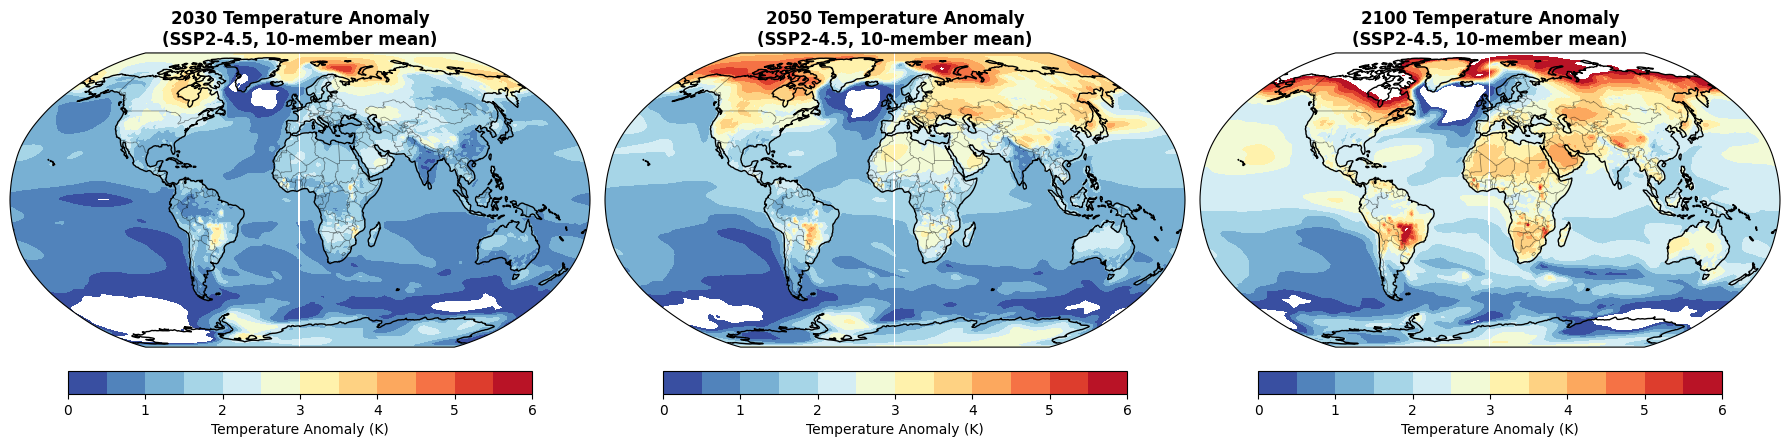

✅ Example 4 complete


In [12]:
# Plot: Ensemble mean warming patterns for 2030, 2050, 2100
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(18, 5))

years_to_plot = [2030, 2050, 2100]
for idx, year in enumerate(years_to_plot):
    ax = fig.add_subplot(1, 3, idx+1, projection=ccrs.Robinson())
    
    # Get ensemble mean for this year
    field = ensemble_gridded['tas'].gridded['annual'][year]
    field_mean = field.mean(dim='realization')  # Average across realizations
    
    # Plot
    im = ax.contourf(
        field_mean.coords['lon'], 
        field_mean.coords['lat'], 
        field_mean.values,
        levels=np.linspace(0, 6, 13),
        cmap='RdYlBu_r',
        transform=ccrs.PlateCarree()
    )
    
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)
    ax.set_title(f'{year} Temperature Anomaly\n(SSP2-4.5, 10-member mean)', 
                 fontsize=12, fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label('Temperature Anomaly (K)', fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Example 4 complete")

## Example 5: Climatology Without Noise

Generate pattern scaling output only (no stochastic variability).

In [13]:
# Generate climatology - useful for deterministic scenarios or baseline projections
climatology = emulator.generate_ensemble_outputs(
    scenario='ssp245',
    start_year=1850,
    end_year=2100,
    n_realizations=1,  # Automatically set to 1 when include_noise=False
    timeseries=['global', 'regional:NEU'],
    include_noise=False  # Skip noise generation
)

# Access climatology (shape will be (1, time) for consistency)
global_climatology = climatology['tas'].timeseries['global']  # Shape: (1, 3012)
print(f"Climatology shape: {global_climatology.shape}")

# Generate ensemble with noise for comparison
ensemble_with_noise = emulator.generate_ensemble_outputs(
    scenario='ssp245',
    start_year=2020,
    end_year=2100,
    n_realizations=100,
    timeseries=['global'],
    include_noise=True
)

Generating ensemble for ssp245
  Years: 1850-2100
  Realizations: 1

📊 Generating TAS...
   → Time series: 2 aggregations
      → Computing pattern scaling for tas, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Climatology only (no stochastic variability)
      • global
      • regional:NEU
   ✅ TAS complete

📊 Generating PR...
   → Time series: 2 aggregations
      → Computing pattern scaling for pr, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for pr...
      → Using 1850 baseline for PR instead of piControl
      → Climatology only (no stochastic variability)
      • global
      • regional:NEU
   ✅ PR complete

✅ Generation complete
Climatology shape: (1, 3012)
Generating ensemble for ssp245
  Years: 2020-2100
  Realizations: 100

📊 Generating TAS...
   → Time series: 1 aggregations
      → Computing pat

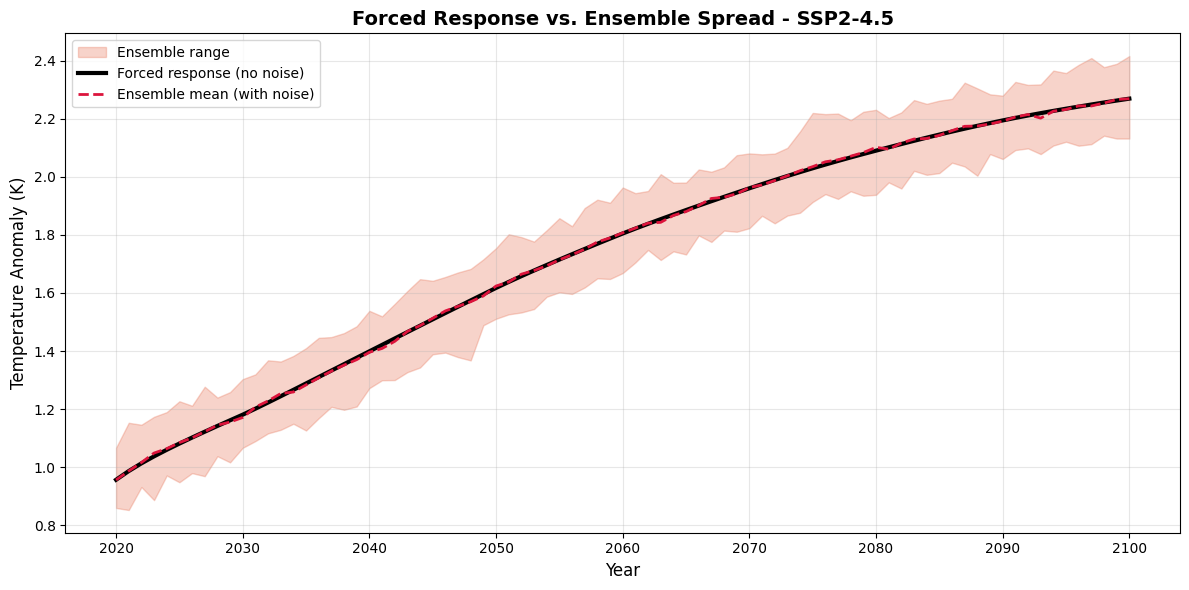

✅ Example 5 complete


In [14]:
# Plot: forced response + ensemble spread
fig, ax = plt.subplots(figsize=(12, 6))

# Simple monthly to annual conversion
def monthly_to_annual(x):
    return x.reshape(-1, 12).mean(axis=1)

# Get data for 2020-2100
n_months_2020 = (2020 - 1850) * 12
years_plot = np.arange(2020, 2101)

# Forced response (climatology)
forced = monthly_to_annual(global_climatology[0, n_months_2020:])

# Ensemble with noise
ensemble = ensemble_with_noise['tas'].timeseries['global']
ensemble_annual = np.array([monthly_to_annual(ensemble[i, :]) for i in range(100)])

# Plot
ax.fill_between(years_plot, ensemble_annual.min(axis=0), ensemble_annual.max(axis=0), 
                alpha=0.3, color='#E76F51', label='Ensemble range')
ax.plot(years_plot, forced, 'k-', linewidth=3, label='Forced response (no noise)')
ax.plot(years_plot, ensemble_annual.mean(axis=0), color='#DC143C', 
        linewidth=2, linestyle='--', label='Ensemble mean (with noise)')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature Anomaly (K)', fontsize=12)
ax.set_title('Forced Response vs. Ensemble Spread - SSP2-4.5', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Example 5 complete")

## Example 6: Multi-Scenario Comparison

Compare different emission scenarios.

In [15]:
emulator = MeteorInterface(
    model='NorESM2-MM',
    variables=['tas', 'pr'],
    cache_dir='../cache',
    data_getter_kwargs={
        'exps': ['piControl', 'abrupt-4xCO2', 'historical', 'ssp126', 'ssp245', 'ssp585'],
        'dbe': ['CMIP', 'CMIP', 'CMIP', 'ScenarioMIP', 'ScenarioMIP', 'ScenarioMIP']
    }
)
emulator.train()

print(f"Emulator created for: {emulator.variables}")
print(f"Model: {emulator.model}")
print(f"Scenarios available: ssp126, ssp245, ssp585")

scenarios = ['ssp126', 'ssp245', 'ssp585']
ensembles = {}

for scenario in scenarios:
    print(f"\nGenerating {scenario}...")
    ensembles[scenario] = emulator.generate_ensemble_outputs(
        scenario=scenario,
        start_year=2015,
        end_year=2100,
        n_realizations=3,
        timeseries=['global'],
        verbose=False
    )

# Compare 2100 warming
print("\n2100 Global Warming:")
for scenario in scenarios:
    temp_2100 = ensembles[scenario]['tas'].timeseries['global'][:, -1]
    print(f"  {scenario}: {temp_2100.mean():.2f} ± {temp_2100.std():.2f} K")

Training METEOR emulator for NorESM2-MM
Variables: tas, pr

🔧 Training TAS...
   → Training pattern scaling model...
      ⚠️  Cache miss: Model name mismatch: expected 'cmip6-NorESM2-MM-aer', found 'cmip6-NorESM2-MM-aer-tas'
🔧 Preparing pattern scaling training data for NorESM2-MM...
   ✅ Training data prepared for experiments: ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 351 emission records
   ✅ Config: 1750-2100, emissions start: 1850
📦 Loading cached pattern scaling model from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
   → Training noise model...
Model loaded from ../cache/noise_models/NorESM2-MM_tas_noise_model.pkl
      ✓ Using cached noise model
   ✅ TAS training complete

🔧 Training PR...
   → Training pattern scaling model...
      ⚠️  Cache miss: Model

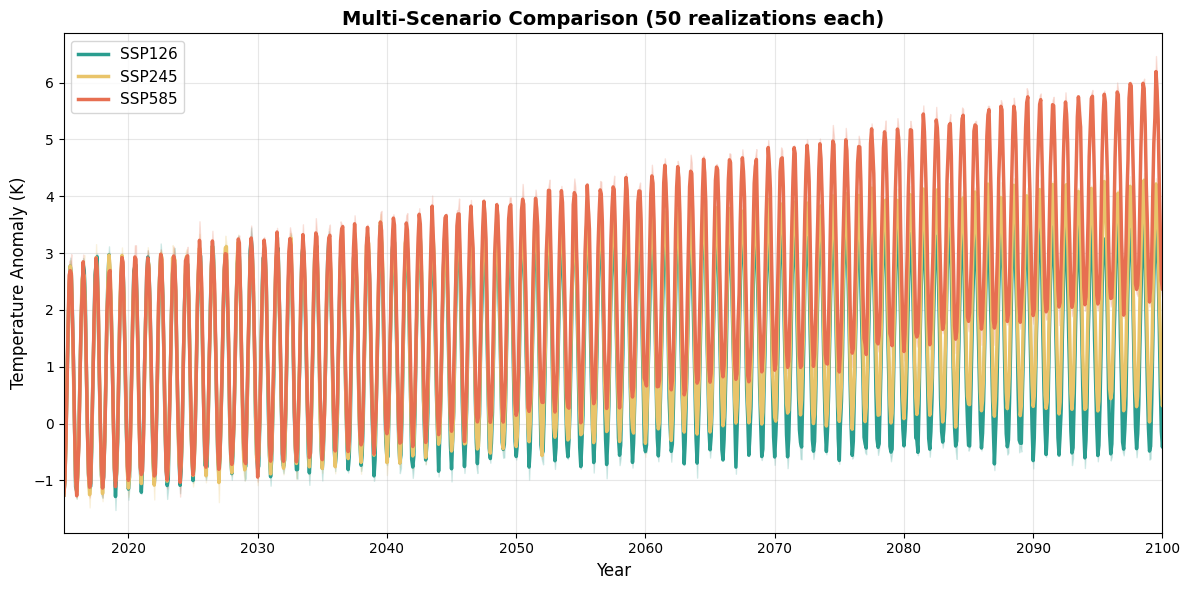

✅ Example 6 complete


In [16]:
# Plot: Multi-scenario comparison
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'ssp126': '#2A9D8F', 'ssp245': '#E9C46A', 'ssp585': '#E76F51'}
n_months_scenario = ensembles['ssp126']['tas'].timeseries['global'].shape[1]
years_scenario = 2015 + np.arange(n_months_scenario) / 12

for scenario in scenarios:
    data = ensembles[scenario]['tas'].timeseries['global']
    color = colors[scenario]
    
    # Plot ensemble spread
    p5 = np.percentile(data, 5, axis=0)
    p95 = np.percentile(data, 95, axis=0)
    ax.fill_between(years_scenario, p5, p95, alpha=0.2, color=color)
    
    # Plot mean
    mean = data.mean(axis=0)
    ax.plot(years_scenario, mean, color=color, linewidth=2.5, label=scenario.upper())

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature Anomaly (K)', fontsize=12)
ax.set_title('Multi-Scenario Comparison (50 realizations each)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([2015, 2100])

plt.tight_layout()
plt.show()

print("✅ Example 6 complete")

# Example 7: Scaling results to a Global Temperature Trajectory

Making an ensemble of ssp126 scaled to ssp245:

In [22]:

# Build scaling timeseries using ssp245 climatology as target
# Pre-1850 values should be 0 (pre-industrial baseline) for METEOR
data_ts = np.zeros(351)
data_ts[:100] = 0.0  # Pre-industrial baseline = 0 K anomaly
data_ts[100:] = global_climatology[0,[(i-1850)*12 for i in range(1850,2101)]]
# Subtract the 1850 value so anomalies are relative to pre-industrial (1750)
data_ts[100:] = data_ts[100:] - global_climatology[0,0]
scaling_ts = xr.DataArray(
    data = data_ts,
    dims = ['year'],
    coords = {
        'year': range(1750,2101)
    }
)   

ensembles_scaled = emulator.generate_ensemble_outputs(
        scenario="ssp126",
        start_year=2015,
        end_year=2100,
        n_realizations=3,
        timeseries=['global'],
        verbose=False,
        temp_scaling_ts = scaling_ts
    )



/Users/bensan/Documents/Github/METEOR/src/meteor/meteor_interface.py:895: RuntimeWarning: invalid value encountered in divide
  temperature_input_anomaly.values / annual_temp_prediction_gm_anomaly.values,


(351,)


/Users/bensan/Documents/Github/METEOR/src/meteor/meteor_interface.py:895: RuntimeWarning: invalid value encountered in divide
  temperature_input_anomaly.values / annual_temp_prediction_gm_anomaly.values,


(351,)


Plotting, comparing scaled ensemble to original ssp126 and ssp245 ensembles

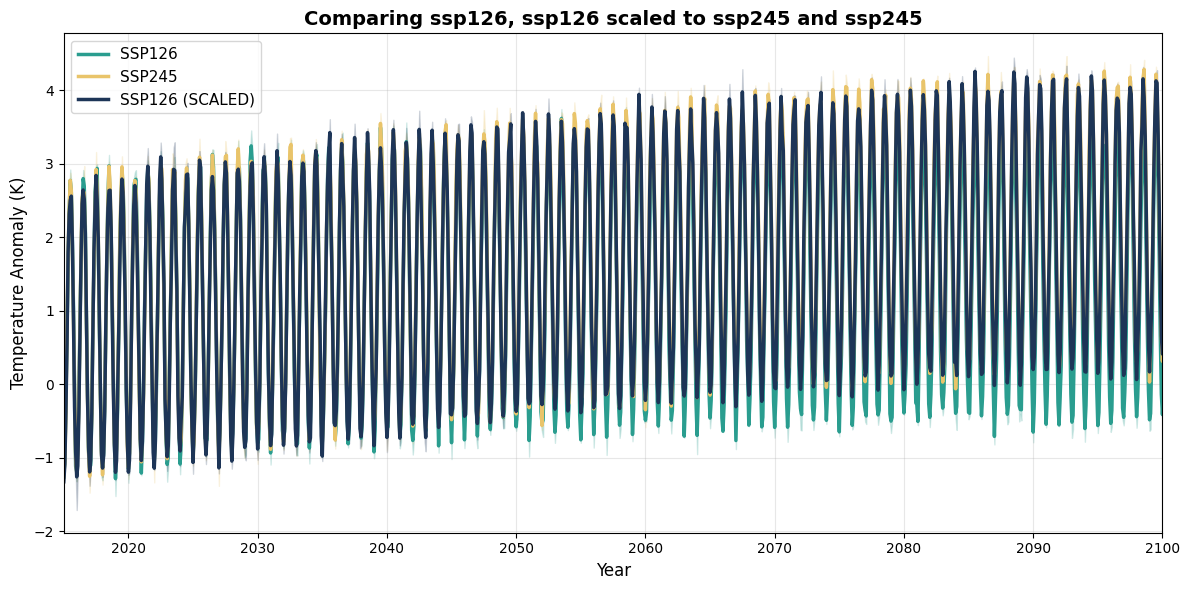

✅ Example 7 complete


In [23]:
# Plot: Multi-scenario comparison
fig, ax = plt.subplots(figsize=(12, 6))

def add_scenario_to_plot(data, scenario, color):
    
    # Plot ensemble spread
    p5 = np.percentile(data, 5, axis=0)
    p95 = np.percentile(data, 95, axis=0)
    ax.fill_between(years_scenario, p5, p95, alpha=0.2, color=color)
    
    # Plot mean
    mean = data.mean(axis=0)
    ax.plot(years_scenario, mean, color=color, linewidth=2.5, label=scenario.upper())

colors = {'ssp126': '#2A9D8F', 'ssp245': '#E9C46A'}
n_months_scenario = ensembles['ssp126']['tas'].timeseries['global'].shape[1]
years_scenario = 2015 + np.arange(n_months_scenario) / 12

for scenario in scenarios:
    if scenario == "ssp585":
        continue  # Skip the unscaled scenario for this plot
    data = ensembles[scenario]['tas'].timeseries['global']
    color = colors[scenario]
    add_scenario_to_plot(data, scenario, color)

data_scaled = ensembles_scaled['tas'].timeseries['global']
add_scenario_to_plot(data_scaled, 'ssp126 (scaled)', '#1D3557')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature Anomaly (K)', fontsize=12)
ax.set_title('Comparing ssp126, ssp126 scaled to ssp245 and ssp245', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([2015, 2100])

plt.tight_layout()
plt.show()

print("✅ Example 7 complete")

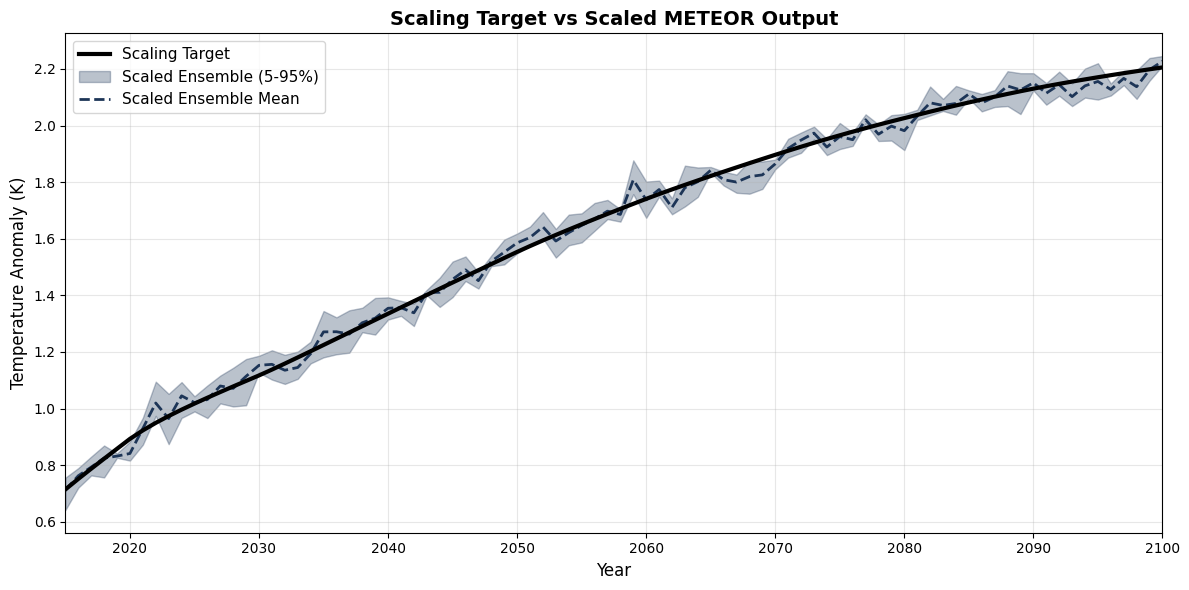

✅ Scaling comparison complete


In [27]:
# Plot: Compare scaling timeseries to scaled METEOR output
fig, ax = plt.subplots(figsize=(12, 6))

# Scaling timeseries (target trajectory) - extract 2015-2100
years_scaling = np.arange(2015, 2101)
scaling_values = scaling_ts.sel(year=years_scaling).values

# Scaled METEOR output - convert monthly to annual means
data_scaled = ensembles_scaled['tas'].timeseries['global']
n_years = len(years_scaling)
scaled_annual = np.array([
    data_scaled[:, i*12:(i+1)*12].mean(axis=1) 
    for i in range(n_years)
]).T  # Shape: (n_realizations, n_years)

# Plot scaling timeseries (target)
ax.plot(years_scaling, scaling_values, 'k-', linewidth=3, label='Scaling Target', zorder=10)

# Plot scaled ensemble spread
p5 = np.percentile(scaled_annual, 5, axis=0)
p95 = np.percentile(scaled_annual, 95, axis=0)
ax.fill_between(years_scaling, p5, p95, alpha=0.3, color='#1D3557', label='Scaled Ensemble (5-95%)')

# Plot scaled ensemble mean
scaled_mean = scaled_annual.mean(axis=0)
ax.plot(years_scaling, scaled_mean, color='#1D3557', linewidth=2, linestyle='--', label='Scaled Ensemble Mean')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature Anomaly (K)', fontsize=12)
ax.set_title('Scaling Target vs Scaled METEOR Output', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([2015, 2100])

plt.tight_layout()
plt.show()

print("✅ Scaling comparison complete")